# Implied Correlation Signal

This notebook will focus on generating signals using implied/realized correlation within equity models

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
path   = r"C:\Users\Diego\Documents\GitHub\TrendSystem\data\FuturesData\PrepFuturesPX.parquet"
df_fut = (pd.read_parquet(
    path =  path, engine = "pyarrow"))

In [3]:
path    = r"C:\Users\Diego\Documents\GitHub\TrendSystem\data\MiscData\CleanedImpliedRealCorrelation.parquet"
df_corr = (pd.read_parquet(
    path = path, engine = "pyarrow").
    query("file == 'ImpliedCorr'").
    drop(columns = ["file", "clean_val"]).
    rename(columns = {
        "variable": "ticker",
        "Date"    : "date"}).
    drop_duplicates())

In [4]:
path = r"C:\Users\Diego\Documents\GitHub\TrendSystem\data\MiscData\ImpliedCorrelationTickerGuide.xlsx"
df_corr_fut_guide = (pd.read_excel(
    io = path, sheet_name = "TickerGuide"))

In [5]:
df_corr_ticker = (df_corr_fut_guide.rename(
    columns = {
        "Equity Index": "equity",
        "Future"      : "future"}).
    assign(
        equity = lambda x: x.equity.str.split(" ").str[0],
        future = lambda x: x.future.str.replace(" 1", "1").str.replace(" ", "_").str.lower()).
    dropna().
    rename(columns = {"future": "ticker"}))

In [6]:
df_prep = (df_fut.merge(
    right = df_corr_ticker, how = "inner", on = ["ticker"])
    [["date", "ticker", "adj_val", "equity"]].
    rename(columns = {
        "ticker": "fut_ticker",
        "equity": "ticker"}).
    assign(date = lambda x: pd.to_datetime(x.date)).
    merge(right = df_corr, how = "inner", on = ["date", "ticker"]))

In [19]:
def _get_baseline_trend(df: pd.DataFrame, vol_window: int = 10, trend_window: int = 100) -> pd.DataFrame: 

    df_out = (df.assign(
        px_diff    = lambda x: x.adj_val.diff(),
        px_dt      = lambda x: x.px_diff / x.px_diff.ewm(span = vol_window, adjust = False).std(),
        px_rtn     = lambda x: x.adj_val.pct_change(),
        signal     = lambda x: x.px_dt.ewm(span = trend_window, adjust = False).mean().shift(),
        signal_rtn = lambda x: np.sign(x.signal) * x.px_rtn))

    return df_out

df_baseline_trend = (df_prep[
    ["date", "fut_ticker", "adj_val"]].
    drop_duplicates().
    set_index("date").
    groupby("fut_ticker").
    apply(_get_baseline_trend, 10, 100).
    reset_index())

In [20]:
def _inf_scaled_rtn_signal(df: pd.DataFrame, diff_window: int = 10, window: int = 100) -> pd.DataFrame: 

    df_out = (df.sort_index().assign(
        px_diff    = lambda x: x.adj_val.diff(),
        px_dt      = lambda x: x.px_diff / x.px_diff.ewm(span = diff_window, adjust = False).std(),
        scaled_dt  = lambda x: x.px_dt * x.value,
        signal     = lambda x: x.scaled_dt.ewm(span = window, adjust = False).mean().shift(),
        px_rtn     = lambda x: x.adj_val.pct_change(),
        signal_rtn = lambda x: np.sign(x.signal) * x.px_rtn))

    return df_out

window        = 100
df_signal_rtn = (df_prep.set_index(
    "date").
    assign(group_var = lambda x: x.fut_ticker + " " + x.window).
    groupby("group_var").
    apply(_inf_scaled_rtn_signal, window).
    reset_index())

In [21]:
fut_namer = (df_signal_rtn[
    ["fut_ticker", "ticker"]].
    drop_duplicates().
    set_index("fut_ticker").
    ticker.
    to_dict())

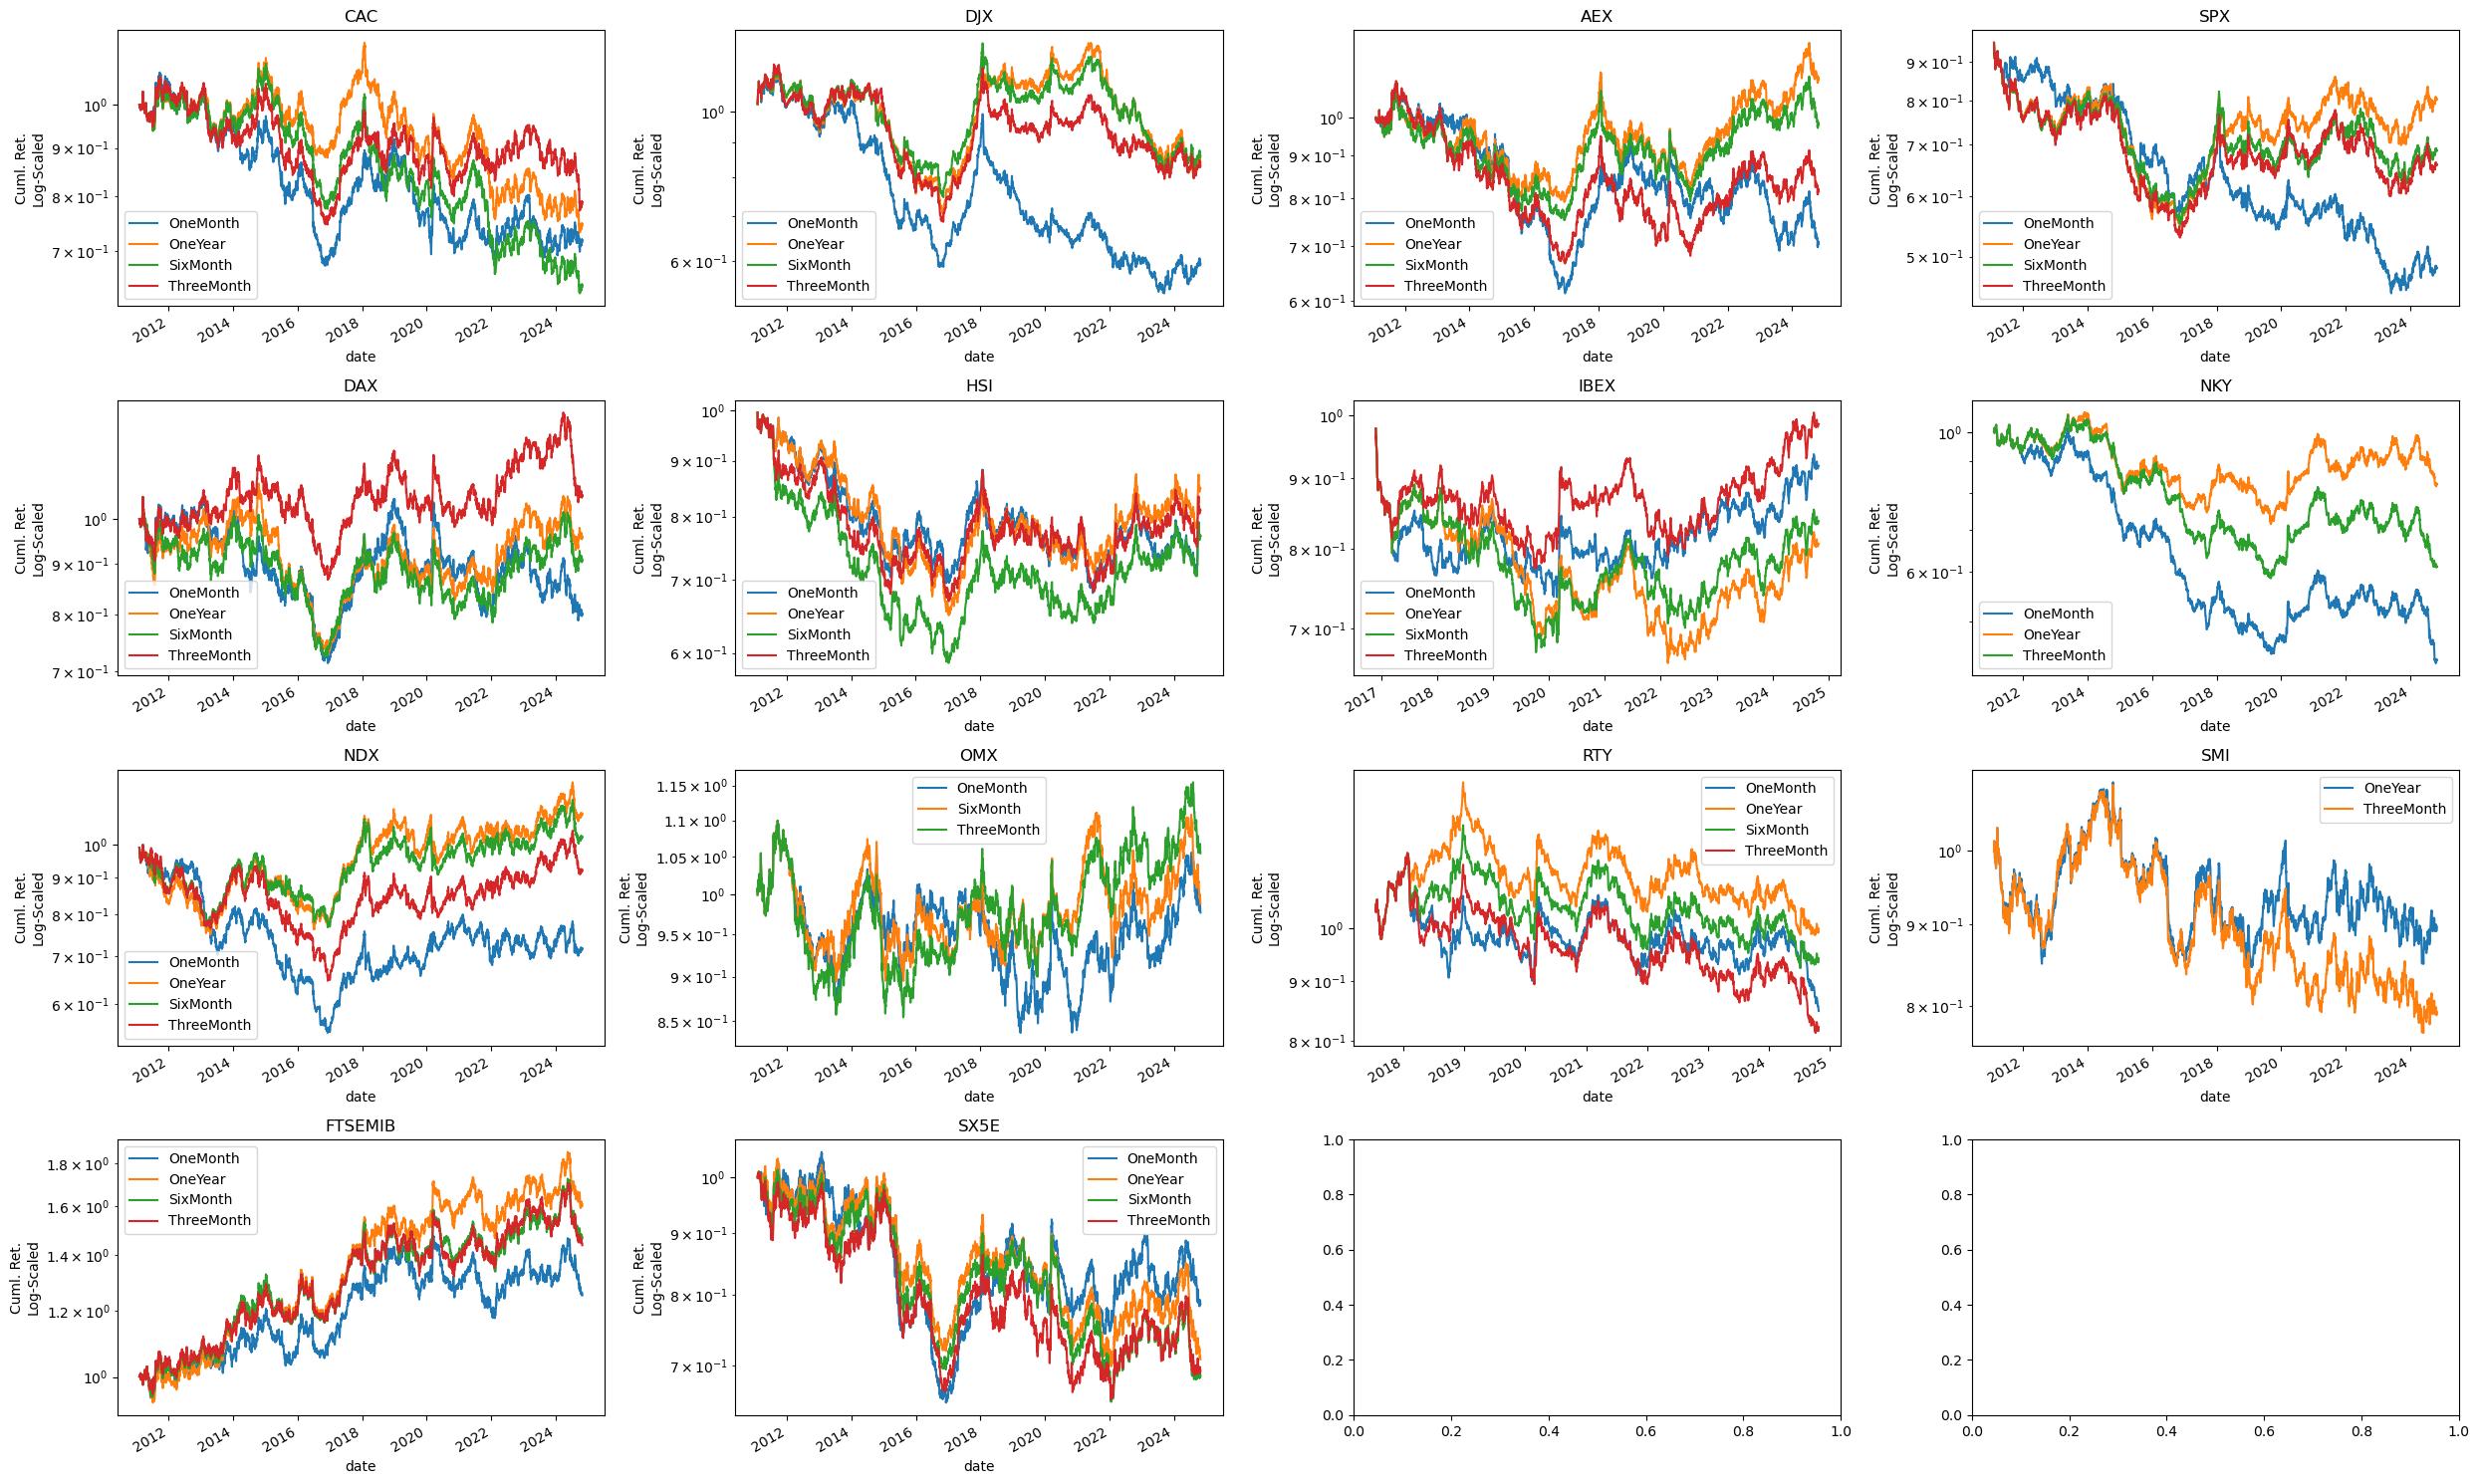

In [23]:
tickers   = df_signal_rtn.fut_ticker.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = 4, nrows = 4, figsize = (25,15))

for ticker, ax in zip(tickers, axes.flatten()): 
    
    (df_signal_rtn.query(
        "fut_ticker == @ticker").
        rename(columns = {"window": ""}).
        pivot(index = "date", columns = "", values = "signal_rtn").
        apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            title  = fut_namer[ticker],
            logy   = True,
            ax     = ax,
            ylabel = "Cuml. Ret.\nLog-Scaled"))

plt.tight_layout()

<Axes: xlabel='window'>

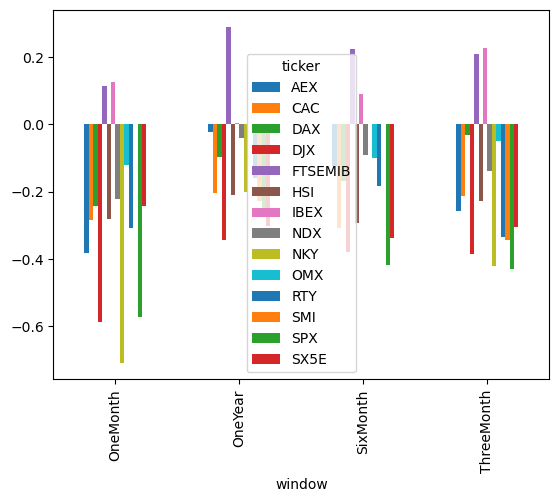

In [24]:
(df_signal_rtn[
    ["ticker", "window", "signal_rtn"]].
    dropna().
    groupby(["ticker", "window"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    pivot(index = "window", columns = "ticker", values = "signal_rtn").
    plot(kind = "bar"))

In [34]:
def _get_scaled_rtn(df: pd.DataFrame) -> pd.DataFrame:

    df_out = (
        df.sort_values("date")
          .assign(
              value   = lambda x: x.value.ffill(),
              px_diff = lambda x: x.adj_val.diff(),
              px_dt   = lambda x: x.px_diff / x.px_diff.ewm(span=10, adjust=False).mean(),
              signal  = lambda x: x.px_dt.ewm(span=100, adjust=False).mean().shift(),
              px_rtn  = lambda x: x.adj_val.pct_change(),

              # Normalize by implied correlation
              px_rtn_ic      = lambda x: x.px_rtn / np.sqrt(x.value),
              px_rtn_ic_lag  = lambda x: x.px_rtn / np.sqrt(x.value.shift()),
              signal_rtn     = lambda x: np.sign(x.signal) * x.px_rtn_ic,
              signal_rtn_lag = lambda x: np.sign(x.signal) * x.px_rtn_ic_lag
          )
    )

    return df_out

df_ic_trend = (
    df_prep
    .set_index("date")
    .assign(group_var=lambda x: x.fut_ticker + " " + x.window)
    .groupby("group_var")
    .apply(_get_scaled_rtn)
    .reset_index()
    .drop(columns = ["group_var"]))

C:\Users\Diego\anaconda3\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Diego\anaconda3\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Diego\anaconda3\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Diego\anaconda3\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Diego\anaconda3\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Diego\anaconda3\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in sq

<Axes: xlabel='date'>

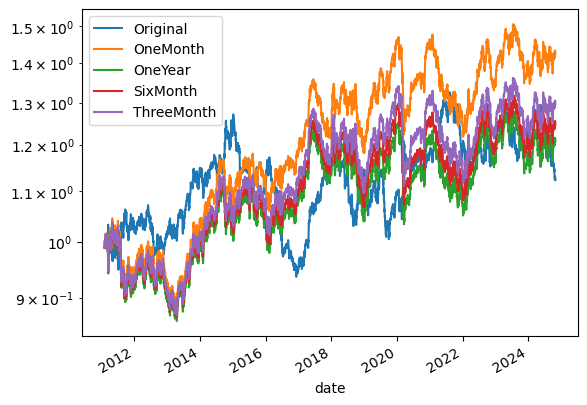

In [52]:
fut_tickers = df_ic_trend.fut_ticker.drop_duplicates().sort_values().to_list()
for fut_ticker in fut_tickers: 

    df_ic_tmp = (df_ic_trend.query(
        "fut_ticker == @fut_ticker").
        pivot(index = "date", columns = "window", values = "signal_rtn"))

    display(df_baseline_trend.query(
        "fut_ticker == @fut_ticker").
        set_index("date")
        [["signal_rtn"]].
        merge(right = df_ic_tmp, how = "inner", on = ["date"]).
        rename(columns = {"signal_rtn": "Original"}).
        apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
        apply(lambda x: np.cumprod(1 + x)).
        plot(logy = True))
    break